# Predicción de churn en telecomunicaciones mediante variables económicas y experiencia de cliente

## Introducción

Análisis y predicción de churn en telecom

El churn o abandono de clientes representa uno de los principales problemas en empresas del sector telecomunicaciones, ya que implica pérdida de ingresos y aumento de costes de captación de nuevos clientes.

El presente trabajo tiene como objetivo analizar los factores asociados al churn utilizando distintas fuentes de información relacionadas con el perfil del cliente, comportamiento económico e interacciones con soporte técnico.

A través de técnicas de análisis exploratorio de datos, ingeniería de variables y modelos predictivos, se busca identificar patrones de comportamiento que permitan anticipar el riesgo de abandono y generar conclusiones útiles desde una perspectiva de negocio.

Los datasets utilizados incluyen información estructural de clientes, facturación mensual, incidencias de soporte y etiquetas de churn.

## Librerías

In [110]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# LIBRERÍAS TEST ESTADÍSTICOS

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

## Funciones Aux.

In [60]:
# ====================================
# FUNCIONES AUXILIARES
# ====================================

def porcentaje_nulos(df):
    
    porcentaje = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
        / len(df)
    ) * 100
    
    return porcentaje

## Carga de datos

In [61]:
# ====================================
# LIBRERÍAS
# ====================================

import pandas as pd
import numpy as np
# ====================================
# CARGA DE DATOS
# ====================================

clientes = pd.read_csv("/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/clientes.csv")

facturacion = pd.read_csv("/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/facturacion_mensual.csv")

soporte = pd.read_csv("/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/interacciones_soporte.csv")

churn = pd.read_csv("/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/churn_target.csv")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuración visual
sns.set(style="whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

## Secciones

In [62]:
# 1. Inspección inicial

# Clientes

clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
1,C000002,Z15,Oeste,suburbana,62939,54.0,M,Casado/a,2,Premium,Gama media,4609.0,35.0,1
2,C000003,Z27,Norte,suburbana,42704,54.0,M,Casado/a,3,Prepago,Gama baja,1836.0,11.0,0
3,C000004,Z22,Este,suburbana,53534,34.0,M,Soltero/a,1,Prepago,Gama media,2318.0,13.0,0
4,C000005,Z04,Centro,suburbana,55457,46.0,F,Soltero/a,2,Contrato,Gama media,2184.0,21.0,0


In [63]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10150 non-null  str    
 1   zona_id           10150 non-null  str    
 2   region            10150 non-null  str    
 3   tipo_zona         10150 non-null  str    
 4   poblacion_zona    10150 non-null  int64  
 5   edad              9845 non-null   float64
 6   sexo              10105 non-null  str    
 7   estado_civil      10071 non-null  str    
 8   num_lineas        10150 non-null  int64  
 9   tipo_plan         10150 non-null  str    
 10  tipo_dispositivo  10150 non-null  str    
 11  ingreso_estimado  9846 non-null   float64
 12  antiguedad_meses  9845 non-null   float64
 13  descuento_activo  10150 non-null  int64  
dtypes: float64(3), int64(3), str(8)
memory usage: 1.1 MB


In [64]:
clientes.describe(include='all')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
count,10150,10150,10150,10150,10150.000000,9845.000000,10105,10071,10150.000000,10150,10150,9846.000000,9845.000000,10150.000000
unique,10000,31,5,3,NaN,NaN,4,4,NaN,3,3,NaN,NaN,NaN
top,C000006,Z26,Oeste,urbana_premium,NaN,NaN,F,Soltero/a,NaN,Premium,Gama media,NaN,NaN,NaN
freq,2,824,3064,4548,NaN,NaN,5125,5584,NaN,5136,6149,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,59980.388571,39.324835,NaN,NaN,2.306207,NaN,NaN,3478.701503,32.599289,0.254975
std,NaN,NaN,NaN,NaN,28712.477075,11.974293,NaN,NaN,1.015997,NaN,NaN,1411.966698,22.512614,0.435869
min,NaN,NaN,NaN,NaN,11707.000000,18.000000,NaN,NaN,1.000000,NaN,NaN,900.000000,-110.000000,0.000000
25%,NaN,NaN,NaN,NaN,41163.000000,31.000000,NaN,NaN,2.000000,NaN,NaN,2467.000000,18.000000,0.000000
50%,NaN,NaN,NaN,NaN,56480.500000,39.000000,NaN,NaN,2.000000,NaN,NaN,3219.000000,29.000000,0.000000
75%,NaN,NaN,NaN,NaN,72683.000000,47.000000,NaN,NaN,3.000000,NaN,NaN,4195.000000,44.000000,1.000000


In [65]:
# ====================================
# VALORES NULOS
# ====================================

porcentaje_nulos(clientes)

edad                3.004926
antiguedad_meses    3.004926
ingreso_estimado    2.995074
estado_civil        0.778325
sexo                0.443350
cliente_id          0.000000
zona_id             0.000000
region              0.000000
tipo_zona           0.000000
poblacion_zona      0.000000
num_lineas          0.000000
tipo_plan           0.000000
tipo_dispositivo    0.000000
descuento_activo    0.000000
dtype: float64

In [66]:
# 1. Análisis exploratorio de datos (EDA)

## 1.1 Variable objetivo

churn.head()

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [67]:
churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [68]:
churn['churn'].value_counts(normalize=True) * 100

churn
0    99.378857
1     0.621143
Name: proportion, dtype: float64

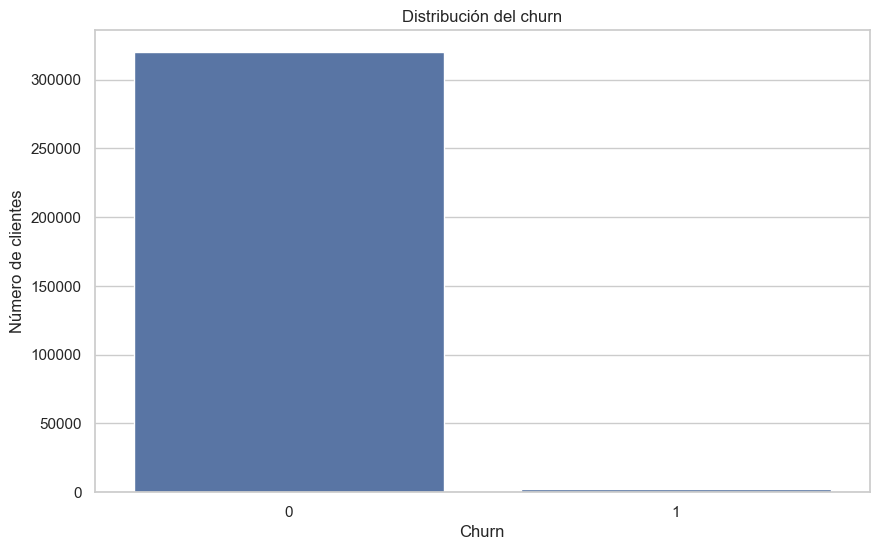

In [69]:
# Gráfico
sns.countplot(
    data=churn,
    x='churn'
)

plt.title("Distribución del churn")

plt.xlabel("Churn")

plt.ylabel("Número de clientes")

plt.show()

### Interpretación

La variable objetivo presenta desbalanceo moderado, ya que el número de clientes que permanecen en la compañía es superior al número de clientes que abandonan el servicio.

Este comportamiento es habitual en problemas reales de churn y deberá tenerse en cuenta en fases posteriores del modelado.

In [70]:
clientes.columns

Index(['cliente_id', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'edad', 'sexo', 'estado_civil', 'num_lineas', 'tipo_plan',
       'tipo_dispositivo', 'ingreso_estimado', 'antiguedad_meses',
       'descuento_activo'],
      dtype='str')

In [71]:
churn.columns

Index(['cliente_id', 'fecha', 'churn'], dtype='str')

In [72]:
df = clientes.merge(
    churn,
    on='cliente_id',
    how='inner'
)

df.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,fecha,churn
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-01-01,0
1,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-02-01,0
2,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-03-01,0
3,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-04-01,0
4,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-05-01,0


## 1.2 Perfil de clientes y churn

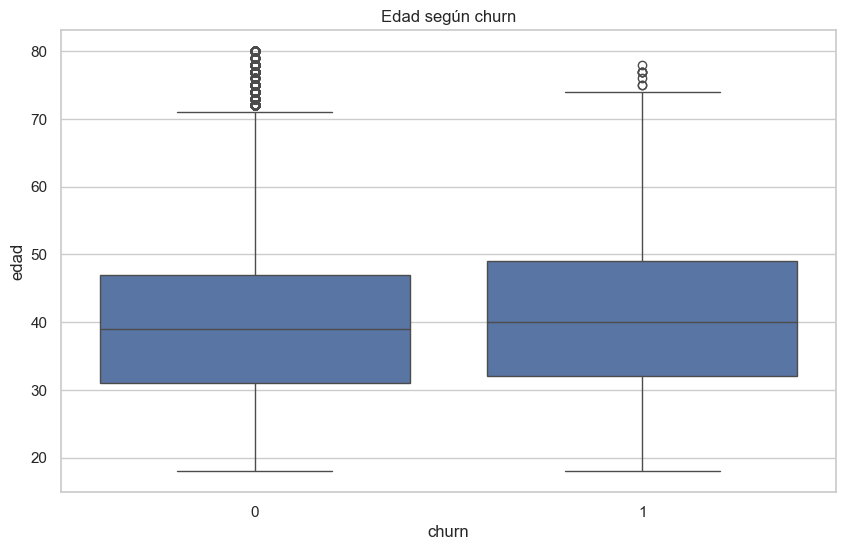

In [73]:
sns.boxplot(
    data=df,
    x='churn',
    y='edad'
)

plt.title("Edad según churn")

plt.show()

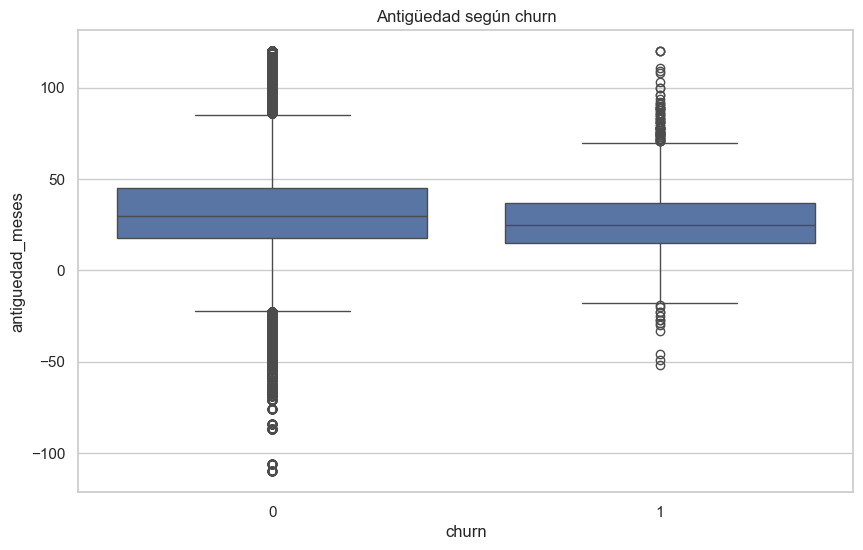

In [74]:
sns.boxplot(
    data=df,
    x='churn',
    y='antiguedad_meses'
)

plt.title("Antigüedad según churn")

plt.show()

In [75]:
tabla_plan = pd.crosstab(
    df['tipo_plan'],
    df['churn'],
    normalize='index'
) * 100

tabla_plan

churn,0,1
tipo_plan,,
Contrato,99.334972,0.665028
Premium,99.512681,0.487319
Prepago,99.155928,0.844072


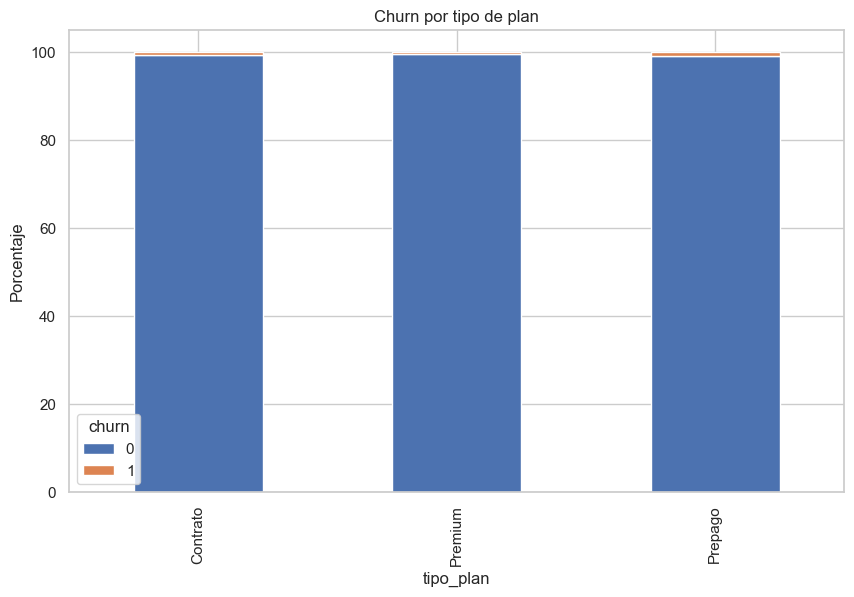

In [76]:
tabla_plan.plot(
    kind='bar',
    stacked=True
)

plt.title("Churn por tipo de plan")

plt.ylabel("Porcentaje")

plt.show()

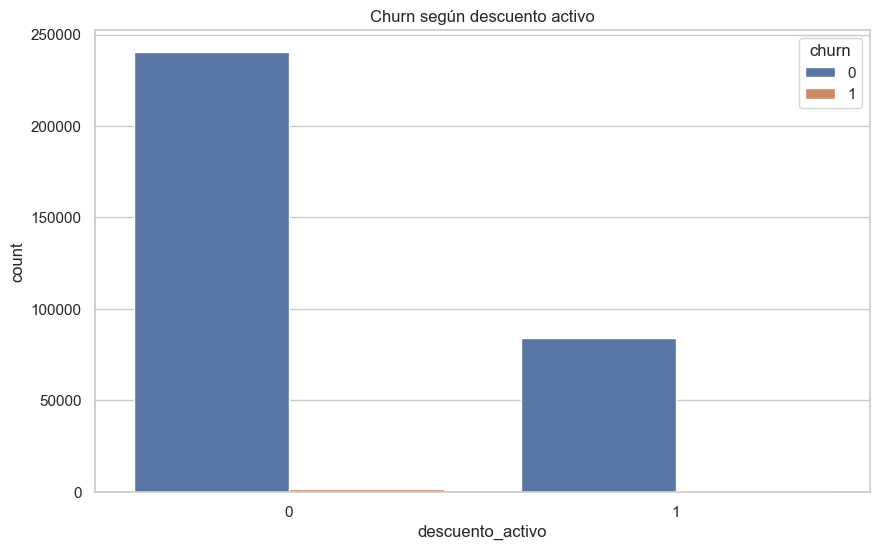

In [77]:
sns.countplot(
    data=df,
    x='descuento_activo',
    hue='churn'
)

plt.title("Churn según descuento activo")

plt.show()

## Conclusiones parciales

A partir del análisis exploratorio inicial se observan diferencias relevantes entre distintos perfiles de clientes.

Variables como la antigüedad, el tipo de plan y la presencia de descuentos parecen mostrar relación con la probabilidad de churn.

Estos resultados permiten plantear hipótesis iniciales que serán analizadas posteriormente mediante técnicas de modelado predictivo.

## FACTURACIÓN


In [78]:
facturacion.columns

Index(['cliente_id', 'fecha', 'zona_id', 'tipo_plan', 'num_lineas',
       'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total',
       'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct',
       'stress_calidad_lag', 'incidencia_masiva_lag'],
      dtype='str')

In [79]:
facturacion.head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
0,C000001,2023-01-01,Z26,Prepago,2,43.65,6.98,0.0,50.62,0,0,0.000,0.0000,0
1,C000001,2023-02-01,Z26,Prepago,2,43.65,10.33,0.0,53.98,0,0,0.481,0.4104,0
2,C000001,2023-03-01,Z26,Prepago,2,43.65,10.87,0.0,54.52,0,0,0.052,0.4221,0
3,C000001,2023-04-01,Z26,Prepago,2,43.65,6.82,0.0,50.47,0,0,-0.372,0.4301,0
4,C000001,2023-05-01,Z26,Prepago,2,43.65,13.26,0.0,56.90,0,0,0.943,0.4486,0


## SOPORTE


In [80]:
soporte.columns

Index(['interaccion_id', 'cliente_id', 'fecha_evento', 'mes', 'canal',
       'motivo', 'duracion_min', 'resuelto', 'satisfaccion_post',
       'stress_calidad_lag', 'incidencia_masiva_lag', 'impago_mes',
       'dias_retraso_mes'],
      dtype='str')

In [81]:
soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


## CHURN

In [82]:
churn.head()


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


# 2. Integración y preparación de datos

In [83]:
# ====================================
# CONVERSIÓN DE FECHAS
# ====================================

facturacion['fecha'] = pd.to_datetime(
    facturacion['fecha'],
    format='mixed',
    dayfirst=True
)

churn['fecha'] = pd.to_datetime(
    churn['fecha'],
    format='mixed',
    dayfirst=True
)

soporte['mes'] = pd.to_datetime(
    soporte['mes'],
    format='mixed',
    dayfirst=True
)

In [84]:
soporte = soporte.rename(
    columns={'mes': 'fecha'}
)

In [85]:
df = churn.merge(
    clientes,
    on='cliente_id',
    how='left'
)

In [86]:
df = df.merge(
    facturacion,
    on=['cliente_id', 'fecha'],
    how='left'
)

In [87]:
# ====================================
# AGREGACIÓN SOPORTE
# ====================================

soporte_agg = soporte.groupby(
    ['cliente_id', 'fecha']
).agg({
    
    'interaccion_id': 'count',
    'duracion_min': 'mean',
    'resuelto': 'mean',
    'satisfaccion_post': 'mean',
    'impago_mes': 'max',
    'dias_retraso_mes': 'mean'
    
}).reset_index()

In [88]:
soporte_agg.columns = [
    'cliente_id',
    'fecha',
    'num_interacciones',
    'duracion_media',
    'ratio_resolucion',
    'satisfaccion_media',
    'impago_mes',
    'dias_retraso'
]

soporte_agg.head()

,cliente_id,fecha,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-02,1,9.50,0.0,4.0,0,0.0
1,C000001,2023-01-04,2,3.35,1.0,4.5,0,0.0
2,C000001,2023-01-05,1,8.40,1.0,3.0,0,0.0
3,C000001,2023-01-06,1,4.50,1.0,4.0,0,0.0
4,C000001,2023-01-10,1,7.90,1.0,4.0,0,0.0


In [89]:
# ====================================
# MERGE SOPORTE
# ====================================

df = df.merge(
    soporte_agg,
    on=['cliente_id', 'fecha'],
    how='left'
)

df.head()

,cliente_id,fecha,churn,zona_id_x,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,...,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-01,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.000,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,C000001,2023-01-02,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.481,0.4104,0.0,1.0,9.50,0.0,4.0,0.0,0.0
2,C000001,2023-01-03,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.052,0.4221,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,C000001,2023-01-04,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,-0.372,0.4301,0.0,2.0,3.35,1.0,4.5,0.0,0.0
4,C000001,2023-01-05,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.943,0.4486,0.0,1.0,8.40,1.0,3.0,0.0,0.0


In [90]:
df.shape

(331690, 34)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331690 entries, 0 to 331689
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cliente_id             331690 non-null  str           
 1   fecha                  331690 non-null  datetime64[us]
 2   churn                  331690 non-null  int64         
 3   zona_id_x              331690 non-null  str           
 4   region                 331690 non-null  str           
 5   tipo_zona              331690 non-null  str           
 6   poblacion_zona         331690 non-null  int64         
 7   edad                   321758 non-null  float64       
 8   sexo                   330275 non-null  str           
 9   estado_civil           329101 non-null  str           
 10  num_lineas_x           331690 non-null  int64         
 11  tipo_plan_x            331690 non-null  str           
 12  tipo_dispositivo       331690 non-null  str           


# 3. Limpieza y preparación del dataset

In [92]:
# ====================================
# ELIMINAR COLUMNAS DUPLICADAS
# ====================================

df = df.drop(columns=[
    
    'zona_id_y',
    'tipo_plan_y',
    'num_lineas_y'
    
])

In [93]:
df = df.rename(columns={
    
    'zona_id_x': 'zona_id',
    'tipo_plan_x': 'tipo_plan',
    'num_lineas_x': 'num_lineas'
    
})

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331690 entries, 0 to 331689
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cliente_id             331690 non-null  str           
 1   fecha                  331690 non-null  datetime64[us]
 2   churn                  331690 non-null  int64         
 3   zona_id                331690 non-null  str           
 4   region                 331690 non-null  str           
 5   tipo_zona              331690 non-null  str           
 6   poblacion_zona         331690 non-null  int64         
 7   edad                   321758 non-null  float64       
 8   sexo                   330275 non-null  str           
 9   estado_civil           329101 non-null  str           
 10  num_lineas             331690 non-null  int64         
 11  tipo_plan              331690 non-null  str           
 12  tipo_dispositivo       331690 non-null  str           


In [95]:
nulos = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos > 0]

satisfaccion_media       148737
dias_retraso             147161
num_interacciones        147161
impago_mes               147161
ratio_resolucion         147161
duracion_media           147161
importe_total             14255
ingreso_estimado           9933
edad                       9932
antiguedad_meses           9927
dias_retraso_pago          4465
stress_calidad_lag         4465
variacion_consumo_pct      4465
impago_flag                4465
cargo_base                 4465
consumo_extra              4465
descuento_aplicado         4465
incidencia_masiva_lag      4465
estado_civil               2589
sexo                       1415
dtype: int64

## 3.1 Tratamiento de valores nulos

In [96]:
# ====================================
# IMPUTACIÓN VARIABLES SOPORTE
# ====================================

df['num_interacciones'] = df['num_interacciones'].fillna(0)

df['duracion_media'] = df['duracion_media'].fillna(0)

df['ratio_resolucion'] = df['ratio_resolucion'].fillna(0)

df['satisfaccion_media'] = df['satisfaccion_media'].fillna(0)

df['impago_mes'] = df['impago_mes'].fillna(0)

df['dias_retraso'] = df['dias_retraso'].fillna(0)

In [97]:
df['edad'] = df['edad'].fillna(
    df['edad'].median()
)

df['ingreso_estimado'] = df['ingreso_estimado'].fillna(
    df['ingreso_estimado'].median()
)

df['antiguedad_meses'] = df['antiguedad_meses'].fillna(
    df['antiguedad_meses'].median()
)

In [98]:
df['sexo'] = df['sexo'].fillna(
    df['sexo'].mode()[0]
)

df['estado_civil'] = df['estado_civil'].fillna(
    df['estado_civil'].mode()[0]
)

In [99]:
df.isnull().sum().sort_values(ascending=False)

importe_total            14255
cargo_base                4465
incidencia_masiva_lag     4465
stress_calidad_lag        4465
variacion_consumo_pct     4465
impago_flag               4465
dias_retraso_pago         4465
descuento_aplicado        4465
consumo_extra             4465
cliente_id                   0
impago_mes                   0
satisfaccion_media           0
ratio_resolucion             0
duracion_media               0
num_interacciones            0
descuento_activo             0
fecha                        0
antiguedad_meses             0
ingreso_estimado             0
tipo_dispositivo             0
tipo_plan                    0
num_lineas                   0
estado_civil                 0
sexo                         0
edad                         0
poblacion_zona               0
tipo_zona                    0
region                       0
zona_id                      0
churn                        0
dias_retraso                 0
dtype: int64

In [100]:
# ====================================
# IMPUTACIÓN VARIABLES FACTURACIÓN
# ====================================

variables_facturacion = [
    
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',
    'stress_calidad_lag',
    'incidencia_masiva_lag'
]

for col in variables_facturacion:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

In [101]:
df.isnull().sum().sort_values(ascending=False)

cliente_id               0
cargo_base               0
impago_mes               0
satisfaccion_media       0
ratio_resolucion         0
duracion_media           0
num_interacciones        0
incidencia_masiva_lag    0
stress_calidad_lag       0
variacion_consumo_pct    0
impago_flag              0
dias_retraso_pago        0
importe_total            0
descuento_aplicado       0
consumo_extra            0
descuento_activo         0
fecha                    0
antiguedad_meses         0
ingreso_estimado         0
tipo_dispositivo         0
tipo_plan                0
num_lineas               0
estado_civil             0
sexo                     0
edad                     0
poblacion_zona           0
tipo_zona                0
region                   0
zona_id                  0
churn                    0
dias_retraso             0
dtype: int64

# 4. Análisis exploratorio avanzado

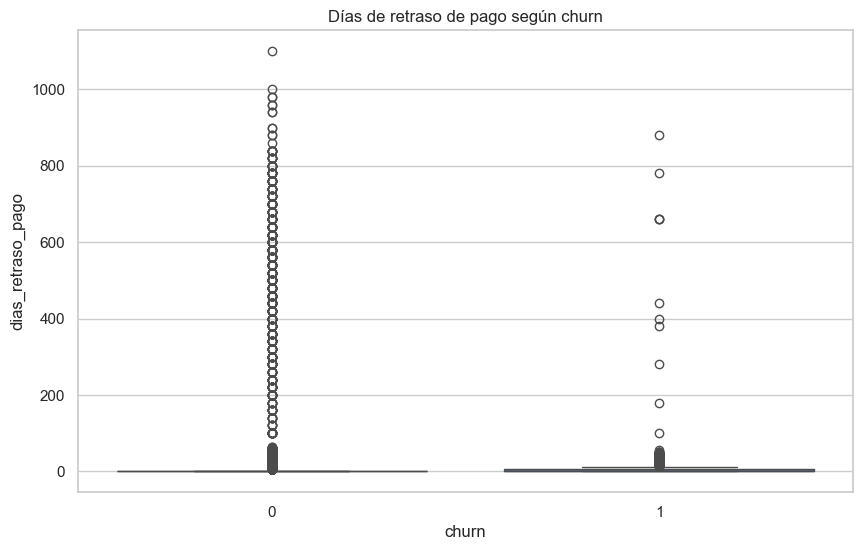

In [108]:
## Churn vs Impago
sns.boxplot(
    data=df,
    x='churn',
    y='dias_retraso_pago'
)

plt.title("Días de retraso de pago según churn")

plt.show()

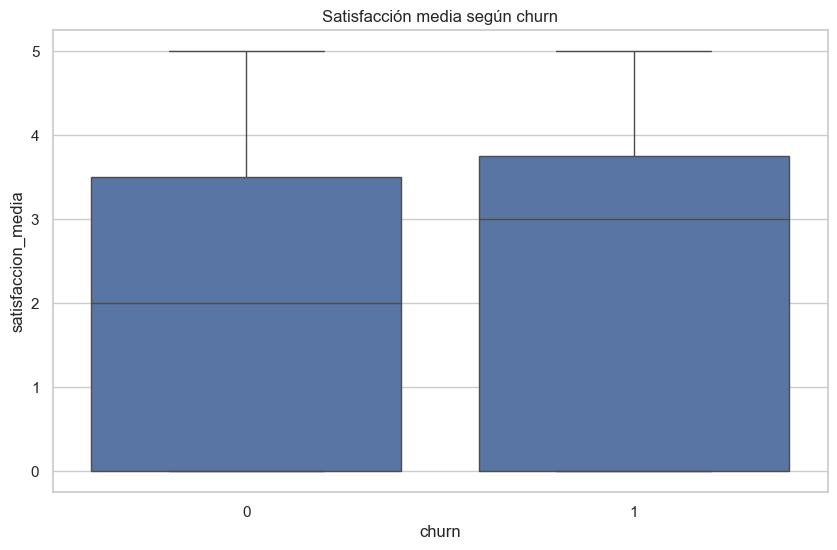

In [103]:
#Churn vs Satisfacción
sns.boxplot(
    data=df,
    x='churn',
    y='satisfaccion_media'
)

plt.title("Satisfacción media según churn")

plt.show()

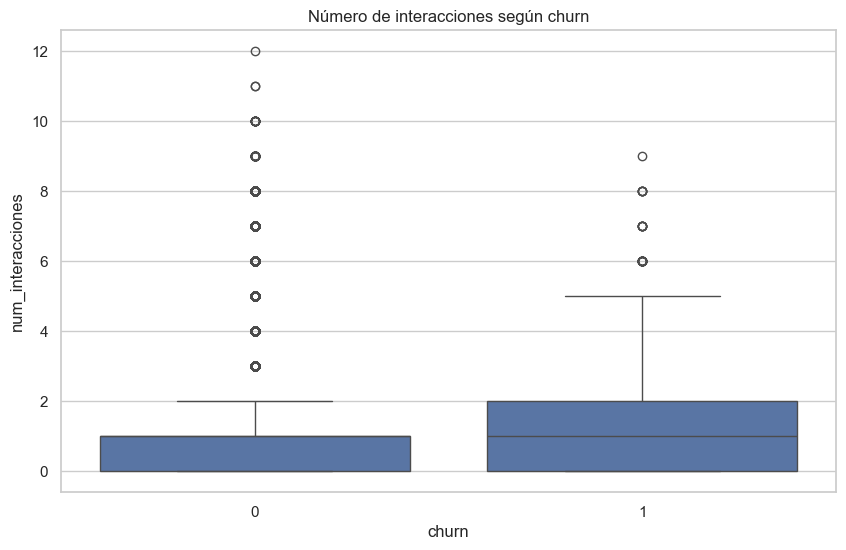

In [104]:
#Churn vs Incidencias

sns.boxplot(
    data=df,
    x='churn',
    y='num_interacciones'
)

plt.title("Número de interacciones según churn")

plt.show()

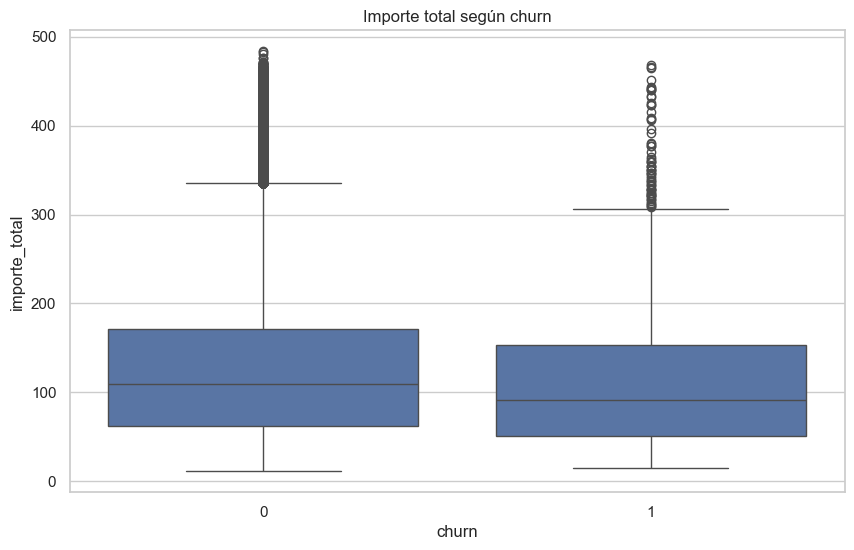

In [105]:
#Churn vs importe factura

sns.boxplot(
    data=df,
    x='churn',
    y='importe_total'
)

plt.title("Importe total según churn")

plt.show()

# 5. Test estadísticos

Con el objetivo de complementar el análisis exploratorio realizado previamente, se aplican distintos test estadísticos para evaluar si existen relaciones significativas entre determinadas variables y el churn.

En particular, se analizarán variables numéricas mediante test t de diferencia de medias y variables categóricas mediante test chi-cuadrado de independencia.

Estos análisis permiten validar parcialmente las hipótesis planteadas durante las fases iniciales del proyecto.

## 5.1 Retraso de pago y churn

Se analiza si existen diferencias estadísticamente significativas en los días de retraso de pago entre clientes con churn y clientes sin churn.

Hipótesis:

- H0: No existen diferencias significativas entre ambos grupos.
- H1: Existen diferencias significativas entre ambos grupos.

In [111]:
# ====================================
# TEST T
# RETRASO PAGO VS CHURN
# ====================================

grupo_churn = df[
    df['churn'] == 1
]['dias_retraso_pago']

grupo_no_churn = df[
    df['churn'] == 0
]['dias_retraso_pago']

t_stat, p_value = ttest_ind(
    grupo_churn,
    grupo_no_churn,
    nan_policy='omit'
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

T-statistic: 11.5096
P-value: 0.0


In [112]:
# ====================================
# INTERPRETACIÓN
# ====================================

if p_value < 0.05:
    
    print(
        "Se rechaza la hipótesis nula. "
        "Existen diferencias estadísticamente significativas "
        "entre clientes con churn y sin churn."
    )

else:
    
    print(
        "No se encontraron diferencias estadísticamente significativas."
    )

Se rechaza la hipótesis nula. Existen diferencias estadísticamente significativas entre clientes con churn y sin churn.


## 5.2 Satisfacción y churn

Se evalúa si la satisfacción media de las interacciones de soporte presenta diferencias significativas entre clientes churn y no churn.

In [113]:
# ====================================
# TEST T
# SATISFACCIÓN VS CHURN
# ====================================

grupo_churn = df[
    df['churn'] == 1
]['satisfaccion_media']

grupo_no_churn = df[
    df['churn'] == 0
]['satisfaccion_media']

t_stat, p_value = ttest_ind(
    grupo_churn,
    grupo_no_churn,
    nan_policy='omit'
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

T-statistic: 10.8798
P-value: 0.0


In [115]:
if p_value < 0.05:
    
    print(
        "Existen diferencias estadísticamente significativas "
        "en satisfacción entre ambos grupos."
    )

else:
    
    print(
        "No se encontraron diferencias estadísticamente significativas."
    )

Existen diferencias estadísticamente significativas en satisfacción entre ambos grupos.


## 5.3 Tipo de plan y churn

Se aplica un test chi-cuadrado para analizar si existe asociación entre el tipo de plan contratado y el churn.

In [117]:
# ====================================
# CHI-CUADRADO
# TIPO PLAN VS CHURN
# ====================================

tabla = pd.crosstab(
    df['tipo_plan'],
    df['churn']
)

chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi2:", round(chi2, 4))
print("P-value:", round(p_value, 6))

Chi2: 120.9313
P-value: 0.0


In [118]:
if p_value < 0.05:
    
    print(
        "Existe asociación estadísticamente significativa "
        "entre tipo de plan y churn."
    )

else:
    
    print(
        "No se encontró asociación significativa."
    )

Existe asociación estadísticamente significativa entre tipo de plan y churn.


## 5.4 Descuento activo y churn

Se evalúa si la presencia de descuentos activos está asociada al churn mediante un test chi-cuadrado.

In [119]:
# ====================================
# CHI-CUADRADO
# DESCUENTO VS CHURN
# ====================================

tabla = pd.crosstab(
    df['descuento_activo'],
    df['churn']
)

chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi2:", round(chi2, 4))
print("P-value:", round(p_value, 6))

Chi2: 12.6024
P-value: 0.000385


In [120]:
if p_value < 0.05:
    
    print(
        "Existe asociación estadísticamente significativa "
        "entre descuento activo y churn."
    )

else:
    
    print(
        "No se encontró asociación significativa."
    )

Existe asociación estadísticamente significativa entre descuento activo y churn.


## Conclusiones de los test estadísticos

Los resultados obtenidos muestran evidencia de relación entre distintas variables económicas y relacionales con el churn.

En particular, variables relacionadas con retrasos de pago, satisfacción del cliente y características del plan contratado presentan asociaciones relevantes con la probabilidad de abandono.

Estos resultados respaldan parcialmente las hipótesis planteadas inicialmente y justifican la inclusión de dichas variables en las siguientes fases de feature engineering y modelado predictivo.

# 6. Feature Engineering

En esta fase se construyen nuevas variables predictivas a partir de la información histórica de los clientes.

El objetivo del feature engineering es incorporar señales temporales y de comportamiento que permitan mejorar la capacidad predictiva del modelo de churn.

Para evitar leakage, las variables temporales se construyen utilizando únicamente información disponible antes del momento de predicción.

## 6.1 Orden temporal del dataset

In [121]:
# ====================================
# ORDEN TEMPORAL
# ====================================

df = df.sort_values(
    ['cliente_id', 'fecha']
)

df.head()

,cliente_id,fecha,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,...,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-01,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.000,0.0000,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,C000001,2023-01-02,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.481,0.4104,0.0,1.0,9.50,0.0,4.0,0.0,0.0
2,C000001,2023-01-03,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.052,0.4221,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,C000001,2023-01-04,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,-0.372,0.4301,0.0,2.0,3.35,1.0,4.5,0.0,0.0
4,C000001,2023-01-05,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.943,0.4486,0.0,1.0,8.40,1.0,3.0,0.0,0.0


## 6.2 Variables lag

Se generan variables lag para incorporar información histórica del cliente.

Estas variables permiten utilizar información de meses anteriores para predecir churn en el periodo actual.

In [122]:
# ====================================
# LAG FACTURACIÓN
# ====================================

df['importe_total_lag1'] = (
    df.groupby('cliente_id')['importe_total']
    .shift(1)
)

In [123]:
# ====================================
# LAG RETRASO PAGO
# ====================================

df['retraso_pago_lag1'] = (
    df.groupby('cliente_id')['dias_retraso_pago']
    .shift(1)
)

In [124]:
# ====================================
# LAG SATISFACCIÓN
# ====================================

df['satisfaccion_lag1'] = (
    df.groupby('cliente_id')['satisfaccion_media']
    .shift(1)
)

In [125]:
# ====================================
# LAG INTERACCIONES
# ====================================

df['interacciones_lag1'] = (
    df.groupby('cliente_id')['num_interacciones']
    .shift(1)
)

In [126]:
df[[
    'cliente_id',
    'fecha',
    'importe_total',
    'importe_total_lag1'
]].head(10)

,cliente_id,fecha,importe_total,importe_total_lag1
0,C000001,2023-01-01,50.62,NaN
1,C000001,2023-01-02,53.98,50.62
2,C000001,2023-01-03,54.52,53.98
3,C000001,2023-01-04,50.47,54.52
4,C000001,2023-01-05,56.90,50.47
5,C000001,2023-01-05,56.90,56.90
6,C000001,2023-01-06,54.14,56.90
7,C000001,2023-01-07,43.65,54.14
8,C000001,2023-01-08,46.32,43.65
9,C000001,2023-01-09,46.77,46.32


## 6.3 Rolling windows

Se construyen variables agregadas móviles utilizando ventanas temporales de varios meses.

Estas variables permiten capturar tendencias recientes y suavizar comportamientos puntuales.

In [127]:
# ====================================
# MEDIA RETRASO 3M
# ====================================

df['media_retraso_3m'] = (
    df.groupby('cliente_id')['dias_retraso_pago']
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

In [128]:
# ====================================
# MEDIA INTERACCIONES 3M
# ====================================

df['media_interacciones_3m'] = (
    df.groupby('cliente_id')['num_interacciones']
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

In [129]:
# ====================================
# MEDIA FACTURACIÓN 3M
# ====================================

df['media_importe_3m'] = (
    df.groupby('cliente_id')['importe_total']
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

## 6.4 Variables de comportamiento

Además de variables históricas, se generan indicadores de cambio de comportamiento del cliente a lo largo del tiempo.

In [130]:
# ====================================
# CAMBIO FACTURACIÓN
# ====================================

df['variacion_importe_pct'] = (
    df.groupby('cliente_id')['importe_total']
    .pct_change()
)

## 6.5 Variables binarias

Se crean variables binarias para representar situaciones de riesgo relevantes para churn.

In [131]:
# ====================================
# VARIABLE IMPAGO
# ====================================

df['tuvo_impago'] = (
    df['impago_flag'] > 0
).astype(int)

In [132]:
# ====================================
# MUCHAS INTERACCIONES
# ====================================

df['muchas_interacciones'] = (
    df['num_interacciones'] >= 3
).astype(int)

In [133]:
# ====================================
# BAJA SATISFACCIÓN
# ====================================

df['baja_satisfaccion'] = (
    df['satisfaccion_media'] <= 2
).astype(int)

## 6.6 Tratamiento de nulos generados por lags

In [134]:
# ====================================
# ELIMINAR NULOS GENERADOS
# ====================================

df = df.dropna()

df.shape

(311708, 42)

## 6.7 Revisión final de variables creadas

In [135]:
# ====================================
# VARIABLES CREADAS
# ====================================

nuevas_variables = [

    'importe_total_lag1',
    'retraso_pago_lag1',
    'satisfaccion_lag1',
    'interacciones_lag1',
    'media_retraso_3m',
    'media_interacciones_3m',
    'media_importe_3m',
    'variacion_importe_pct',
    'tuvo_impago',
    'muchas_interacciones',
    'baja_satisfaccion'

]

df[nuevas_variables].head()

,importe_total_lag1,retraso_pago_lag1,satisfaccion_lag1,interacciones_lag1,media_retraso_3m,media_interacciones_3m,media_importe_3m,variacion_importe_pct,tuvo_impago,muchas_interacciones,baja_satisfaccion
2,53.98,0.0,4.0,1.0,0.0,0.333333,53.040000,0.010004,0,0,1
3,54.52,0.0,0.0,0.0,0.0,1.000000,52.990000,-0.074285,0,0,0
4,50.47,0.0,4.5,2.0,0.0,1.000000,53.963333,0.127402,0,0,0
5,56.90,0.0,3.0,1.0,0.0,1.333333,54.756667,0.000000,0,0,0
6,56.90,0.0,3.0,1.0,0.0,1.000000,55.980000,-0.048506,0,0,0


## Conclusiones de feature engineering

Las variables generadas permiten incorporar información histórica y patrones de comportamiento relevantes para la predicción de churn.

En particular, las variables lag y rolling windows ayudan a capturar tendencias temporales y reducen el riesgo de leakage al utilizar únicamente información disponible antes del momento de predicción.

Estas nuevas variables serán utilizadas en la siguiente fase de modelado predictivo.

#

# Conclusiones





7. Modelado benchmark
    - preparación modelado
    - logistic regression

8. Evaluación del modelo
    - métricas
    - matriz confusión
    - interpretación